 # Projeto BCI — Covert Shifts of Attention

## Organização estrutural do notebook

Este notebook organiza o pipeline atual do grupo para análise do dataset *Covert Shifts of Attention (BNCI 005-2015)*.

É fundamental ressaltar que este dataset se situa em um campo de transição metodológica que desafia as classificações clássicas de BCI: ele não representa um SSVEP, pela ausência de estímulos externos intermitentes (flickers) para evocar respostas corticais, não é um ERP tradicional, pois foca em mudanças oscilatórias sustentadas em vez de potenciais transientes sincronizados a eventos e diferencia-se do paradigma SMR padrão por tratar de modulações occipitais de atenção visual encoberta em vez de ritmos sensoriomotores de imagética motora. Portanto, o projeto analisa modulações oscilatórias em banda alfa associadas à atenção visual encoberta, usando uma lógica de processamento inspirada em BCIs visuais baseadas em frequência.

A pergunta operacional do projeto é:

> É possível estimar a direção da atenção visual encoberta a partir de modulações da banda alfa no EEG?

O notebook está organizado em duas abordagens principais:

1. *Baseline espectral:* Welch + Log10 da potência alfa + SVM.
2. *Modelo espacial:* CSP + SVM.

A comparação entre essas duas abordagens sustenta a interpretação central do trabalho: a informação espacial do EEG melhora a separação entre direções de atenção visual.

# 1. Preparação do ambiente


## 1.1 Instalação das bibliotecas


In [1]:
import sys
!{sys.executable} -m ensurepip --default-pip

%pip install --upgrade pip
%pip install numpy scipy gdown matplotlib scikit-learn mne


Defaulting to user installation because normal site-packages is not writeable
Looking in links: c:\Users\Amanda\AppData\Local\Temp\tmp12uguicx
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 1.2 Importação das bibliotecas


In [2]:
import glob
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt, welch

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix

import mne
from mne.preprocessing import ICA
from mne.decoding import CSP


# 2. Carregamento dos dados

Nesta etapa definimos a pasta de trabalho, baixamos os arquivos `.mat` do Google Drive e verificamos se os dados foram encontrados corretamente.


## 2.1 Definir pasta local e link do Google Drive


In [3]:
IN_COLAB = "google.colab" in sys.modules

DATA_DIR = Path("/content/Projeto_BCI" if IN_COLAB else "./Projeto_BCI").resolve()

GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1l2wfRKe3_xGU0otL7aIvcwXn578fGs7a?usp=sharing"

print("Pasta dos dados:", DATA_DIR)

Pasta dos dados: C:\Users\Amanda\Downloads\Nova pasta\Nova pasta\Projeto_BCI


## 2.2 Baixar arquivos `.mat`


In [4]:
if not DATA_DIR.exists():
    import gdown

    print(f"Baixando arquivos para: {DATA_DIR}")
    gdown.download_folder(
        GDRIVE_FOLDER_URL,
        output=str(DATA_DIR),
        quiet=False,
        use_cookies=False
    )
else:
    print("A pasta já existe. Download não realizado novamente.")

A pasta já existe. Download não realizado novamente.


## 2.3 Listar arquivos encontrados


In [5]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mat")))

print(f"{len(files)} arquivos .mat encontrados:")

for file in files:
    print(os.path.basename(file))

8 arquivos .mat encontrados:
covertShiftsOfAttention_VPgao.mat
covertShiftsOfAttention_VPiaa.mat
covertShiftsOfAttention_VPiac.mat
covertShiftsOfAttention_VPiae.mat
covertShiftsOfAttention_VPiah.mat
covertShiftsOfAttention_VPiai.mat
covertShiftsOfAttention_VPmk.mat
covertShiftsOfAttention_VPnh.mat


## 2.4 Carregar sinais EEG e frequência de amostragem


In [6]:
data_list = []
fs_list = []
nomes_arquivos = []

for fname in files:
    nome = os.path.basename(fname)

    mat = loadmat(fname, squeeze_me=True, struct_as_record=False)

    data = mat["data"]

    X = np.asarray(data.X, dtype=float)
    fs = int(data.fs)

    data_list.append(X)
    fs_list.append(fs)
    nomes_arquivos.append(nome)

    print(f"{nome}")
    print(f"  X shape: {X.shape}")
    print(f"  fs: {fs} Hz")
    print()

covertShiftsOfAttention_VPgao.mat
  X shape: (579736, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiaa.mat
  X shape: (581804, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiac.mat
  X shape: (657660, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiae.mat
  X shape: (613408, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiah.mat
  X shape: (604788, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiai.mat
  X shape: (429348, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPmk.mat
  X shape: (592640, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPnh.mat
  X shape: (596576, 62)
  fs: 200 Hz



## 2.5 Conferir frequência de amostragem


In [7]:
frequencias = sorted(set(fs_list))

print("Frequências encontradas:", frequencias)

if len(frequencias) == 1:
    fs = frequencias[0]
    print(f"Todos os arquivos têm fs = {fs} Hz")
else:
    print("Atenção: existem frequências diferentes entre os arquivos.")

Frequências encontradas: [200]
Todos os arquivos têm fs = 200 Hz


## 2.6 Conferir formato dos dados


In [8]:
X_exemplo = data_list[0]

print("Shape do primeiro arquivo:", X_exemplo.shape)

n_amostras = X_exemplo.shape[0]
n_canais = X_exemplo.shape[1]

print("Número de amostras:", n_amostras)
print("Número de canais:", n_canais)

Shape do primeiro arquivo: (579736, 62)
Número de amostras: 579736
Número de canais: 62


# 3. Pré-processamento do EEG

O objetivo desta seção é preparar os sinais para análise na banda alfa. O pipeline atual aplica:

- filtro notch em 60 Hz;
- filtro passa-banda entre 8 e 14 Hz;
- inspeção visual inicial dos sinais filtrados.


## 3.1 Criar função de filtragem


In [9]:
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt

def aplicar_filtros_eeg(X, fs):
    X = np.asarray(X, dtype=float)

    b_notch, a_notch = iirnotch(60.0, 30.0, fs)
    X_notch = filtfilt(b_notch, a_notch, X, axis=0)

    sos = butter(
        4,
        [8, 14],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    X_filtrado = sosfiltfilt(sos, X_notch, axis=0)

    return X_filtrado


def aplicar_filtros_eeg_chunked(X, fs, chunk_size=50000):
    X_filtrado = np.zeros_like(X)

    for i in range(0, X.shape[0], chunk_size):
        chunk = X[i:i+chunk_size]
        X_filtrado[i:i+chunk_size] = aplicar_filtros_eeg(chunk, fs)

    return X_filtrado

In [10]:
# célula adicionada para calcular o uso de RAM e o tamanho dos arrays

import os, psutil, numpy as np

process = psutil.Process(os.getpid())

print("RAM usada pelo Python:", round(process.memory_info().rss / 1024**3, 2), "GB")

for i, X in enumerate(data_list):
    tamanho_gb = X.nbytes / 1024**3
    print(i, nomes_arquivos[i], X.shape, X.dtype, round(tamanho_gb, 3), "GB")

RAM usada pelo Python: 2.39 GB
0 covertShiftsOfAttention_VPgao.mat (579736, 62) float64 0.268 GB
1 covertShiftsOfAttention_VPiaa.mat (581804, 62) float64 0.269 GB
2 covertShiftsOfAttention_VPiac.mat (657660, 62) float64 0.304 GB
3 covertShiftsOfAttention_VPiae.mat (613408, 62) float64 0.283 GB
4 covertShiftsOfAttention_VPiah.mat (604788, 62) float64 0.279 GB
5 covertShiftsOfAttention_VPiai.mat (429348, 62) float64 0.198 GB
6 covertShiftsOfAttention_VPmk.mat (592640, 62) float64 0.274 GB
7 covertShiftsOfAttention_VPnh.mat (596576, 62) float64 0.276 GB


## 3.2 Aplicar filtragem em todos os arquivos


In [11]:
data_filtrada = []

idx_participante = 0

X = data_list[idx_participante]
fs = fs_list[idx_participante]
nome = nomes_arquivos[idx_participante]

print(f"Filtrando apenas o participante {idx_participante}: {nome}")

X_filtrado = aplicar_filtros_eeg_chunked(X, fs)

data_filtrada.append(X_filtrado)

print(f"  Antes: {X.shape}")
print(f"  Depois: {X_filtrado.shape}")

Filtrando apenas o participante 0: covertShiftsOfAttention_VPgao.mat
  Antes: (579736, 62)
  Depois: (579736, 62)


## 3.3 Verificar resultado da filtragem


In [12]:
print("Total de arquivos originais:", len(data_list))
print("Total de arquivos filtrados:", len(data_filtrada))

print("\nExemplo do primeiro participante:")
print("Original:", data_list[0].shape)
print("Filtrado:", data_filtrada[0].shape)

Total de arquivos originais: 8
Total de arquivos filtrados: 1

Exemplo do primeiro participante:
Original: (579736, 62)
Filtrado: (579736, 62)


## 3.4 Visualizar canais filtrados


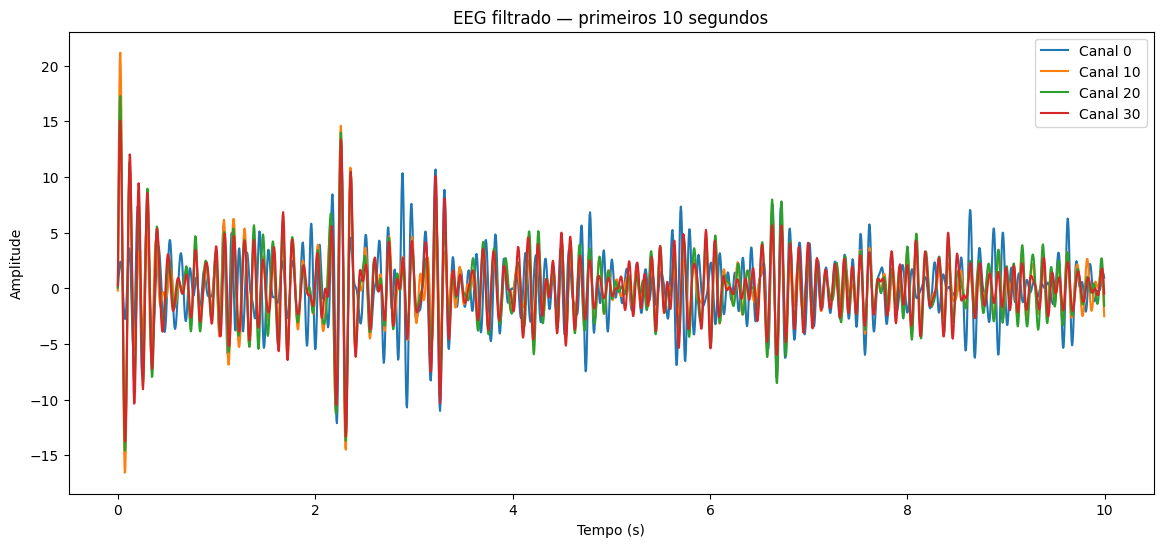

In [13]:
import matplotlib.pyplot as plt

idx_participante = 0
X = data_filtrada[idx_participante]

fs = fs_list[idx_participante]

tempo = np.arange(X.shape[0]) / fs

canais_para_plotar = [0, 10, 20, 30]

plt.figure(figsize=(14,6))

for canal in canais_para_plotar:
    plt.plot(
        tempo[:2000],
        X[:2000, canal],
        label=f"Canal {canal}"
    )

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("EEG filtrado — primeiros 10 segundos")
plt.legend()
plt.show()

In [14]:
# célula adicionada para liberar memória intermediária antes da criação das épocas
# útil para evitar picos de uso de RAM durante a criação das épocas, já que os dados originais e filtrados podem ser grandes

import gc

for var in ["data_list", "X", "X_filtrado", "X_notch", "chunk"]:
    if var in globals():
        del globals()[var]

gc.collect()

print("Memória intermediária liberada antes da criação das épocas.")

Memória intermediária liberada antes da criação das épocas.


# 4. Eventos, labels e criação das épocas

Nesta etapa são inspecionados os marcadores experimentais para construir as épocas do EEG. A lógica atual é usar o intervalo entre **cue** e **target**, pois esse intervalo representa o período em que o participante mantém a atenção encoberta antes do alvo visual.


## 4.1 Inspecionar estrutura dos trials


In [15]:
idx = 0

mat = loadmat(
    files[idx],
    squeeze_me=True,
    struct_as_record=False
)

data = mat["data"]
mrk = mat["mrk"]

trial = data.trial
labels = data.y

print("Número de trials:", len(trial))

print("\nPrimeiros trials:")
print(trial[:10])

print("\nPrimeiros labels:")
print(labels[:10])

Número de trials: 600

Primeiros trials:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros labels:
[2 1 3 1 2 4 3 6 3 3]


## 4.2 Calcular duração dos trials


In [16]:
trial_diff = np.diff(trial)

print("Primeiros tamanhos de trials:")
print(trial_diff[:10])

print("\nMédia:")
print(int(np.mean(trial_diff)))

print("\nMínimo:")
print(np.min(trial_diff))

print("\nMáximo:")
print(np.max(trial_diff))

Primeiros tamanhos de trials:
[1062  825 1063 1062  904  884 1062 1062  859 1062]

Média:
964

Mínimo:
762

Máximo:
1903


## 4.3 Inspecionar eventos cue/target


In [17]:
print("Campos dentro de mrk.target_location:")

if hasattr(mrk.target_location, "_fieldnames"):
    print(mrk.target_location._fieldnames)
else:
    print("Não é struct")

Campos dentro de mrk.target_location:
['pos', 'toe', 'fs', 'y', 'className']


## 4.4 Inspecionar campos de `target_location`


In [18]:
for campo in mrk.target_location._fieldnames:
    valor = getattr(mrk.target_location, campo)

    print("\nCampo:", campo)
    print("Tipo:", type(valor))

    if hasattr(valor, "shape"):
        print("Shape:", valor.shape)

    if hasattr(valor, "__len__"):
        try:
            print("Primeiros valores:")
            print(valor[:20])
        except:
            pass


Campo: pos
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190 11252 12015
 13081 14127 15194 16135 17194 18256 19319 20381]

Campo: toe
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[37 30 32 30 37 39 30 41 37 32 32 34 39 37 34 37 32 41 34 41]

Campo: fs
Tipo: <class 'int'>

Campo: y
Tipo: <class 'numpy.ndarray'>
Shape: (6, 600)
Primeiros valores:
[[0 1 0 ... 0 0 1]
 [1 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Campo: className
Tipo: <class 'numpy.ndarray'>
Shape: (6,)
Primeiros valores:
['target @1' 'target @2' 'target @3' 'target @4' 'target @5' 'target @6']


## 4.5 Calcular delay entre cue e target


In [19]:
cue_pos = data.trial
target_pos = mrk.target_location.pos

print("Primeiros cue_pos:")
print(cue_pos[:10])

print("\nPrimeiros target_pos:")
print(target_pos[:10])

delay = target_pos - cue_pos

print("\nDelay entre cue e target em amostras:")
print(delay[:20])

print("\nDelay médio em segundos:")
print(np.mean(delay) / fs)

print("\nDelay mínimo em segundos:")
print(np.min(delay) / fs)

print("\nDelay máximo em segundos:")
print(np.max(delay) / fs)

Primeiros cue_pos:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros target_pos:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190]

Delay entre cue e target em amostras:
[429 192 430 429 271 250 429 429 225 429 429 129 429 412 433 308 425 429
 430 429]

Delay médio em segundos:
1.621925

Delay mínimo em segundos:
0.645

Delay máximo em segundos:
2.17


## 4.6 Criar épocas alinhadas ao cue

**Observação técnica importante:** neste ponto, o código atual usa `idx_participante = 0`, portanto a criação de épocas está restrita ao primeiro arquivo/participante carregado. Isso deve ser mantido se o grupo decidiu analisar apenas um participante; caso contrário, a etapa precisa ser generalizada para todos os participantes.


In [20]:
idx_participante = 0
X = data_filtrada[0]

cue_pos = data.trial
target_pos = mrk.target_location.pos
target_y = mrk.target_location.y

epochs_cue_target = []
labels_cue_target = []

for i in range(len(cue_pos)):

    inicio = cue_pos[i]
    fim = target_pos[i]

    if fim > inicio and fim <= X.shape[0]:

        epoch = X[inicio:fim, :]

        classe = np.argmax(target_y[:, i])

        epochs_cue_target.append(epoch)
        labels_cue_target.append(classe)

labels_cue_target = np.array(labels_cue_target)

print("Número de epochs criadas:", len(epochs_cue_target))
print("Número de labels:", len(labels_cue_target))

print("\nPrimeiras shapes das epochs:")

for i in range(5):
    print(f"Epoch {i}:", epochs_cue_target[i].shape)

print("\nPrimeiros labels:")
print(labels_cue_target[:10])

Número de epochs criadas: 600
Número de labels: 600

Primeiras shapes das epochs:
Epoch 0: (429, 62)
Epoch 1: (192, 62)
Epoch 2: (430, 62)
Epoch 3: (429, 62)
Epoch 4: (271, 62)

Primeiros labels:
[1 0 2 0 1 3 0 5 1 2]


## 4.7 Padronizar tamanho das épocas pelo menor delay


In [21]:
delay = target_pos - cue_pos

janela_amostras = int(np.min(delay))

print("Janela escolhida (amostras):", janela_amostras)
print("Janela escolhida (segundos):", janela_amostras / fs)

epochs_padronizadas = []
labels_padronizadas = []

for epoch, label in zip(epochs_cue_target, labels_cue_target):

    epoch_fixada = epoch[:janela_amostras, :]

    epochs_padronizadas.append(epoch_fixada)
    labels_padronizadas.append(label)

epochs_padronizadas = np.array(epochs_padronizadas)
labels_padronizadas = np.array(labels_padronizadas)

print("\nShape final das epochs:")
print(epochs_padronizadas.shape)

print("\nShape final dos labels:")
print(labels_padronizadas.shape)

print("\nTotal de trials mantidos:", len(epochs_padronizadas))

Janela escolhida (amostras): 129
Janela escolhida (segundos): 0.645

Shape final das epochs:
(600, 129, 62)

Shape final dos labels:
(600,)

Total de trials mantidos: 600


In [22]:
# célula adicionada para liberar memória intermediária antes da ICA

import gc

for var in ["data_list", "data_filtrada", "X", "X_filtrado", "X_notch", "chunk"]:
    if var in globals():
        del globals()[var]

gc.collect()

print("Memória liberada antes da ICA.")

Memória liberada antes da ICA.


# 5. Limpeza por ICA

A Análise de Componentes Independentes (ICA) foi incluída como etapa de pré-processamento para investigar e, quando justificável, remover componentes associados a artefatos.

Neste notebook, a ICA é aplicada antes da extração das features por Welch e CSP. A remoção de componentes, entretanto, não deve ser feita de forma automática apenas pela numeração do componente, pois a ordem dos componentes ICA não garante que artefatos oculares estejam sempre nos componentes 0, 1 ou 2.

A seleção dos componentes removidos deve ser baseada na inspeção dos mapas topográficos e das séries temporais dos componentes.

## 5.1 Ajustar ICA e visualizar componentes

Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Fitting ICA to data using 62 channels (please be patient, this may take a while)


C:\Users\Amanda\AppData\Local\Temp\ipykernel_16316\1707430402.py:15: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(epochs_mne)


Selecting by number: 20 components
Fitting ICA took 2.9s.
Mapas topográficos dos componentes ICA:


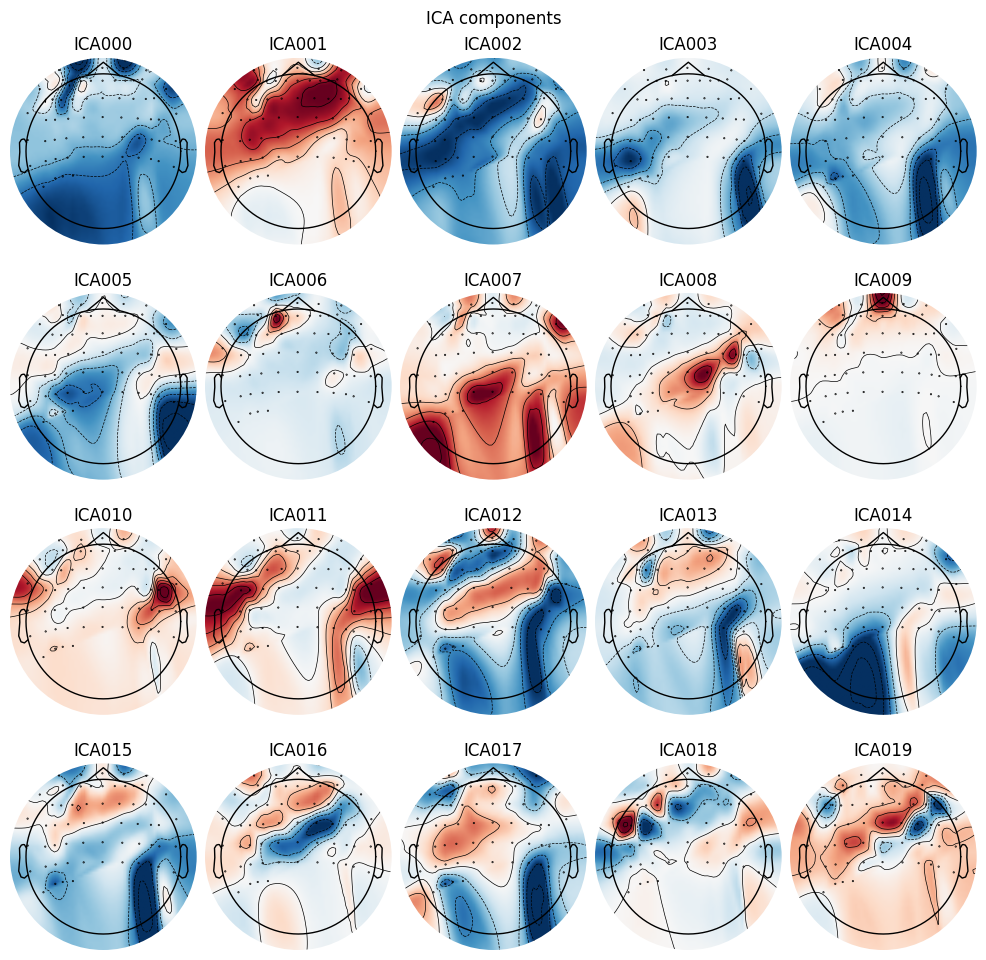

Séries temporais dos componentes ICA:
Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Using matplotlib as 2D backend.


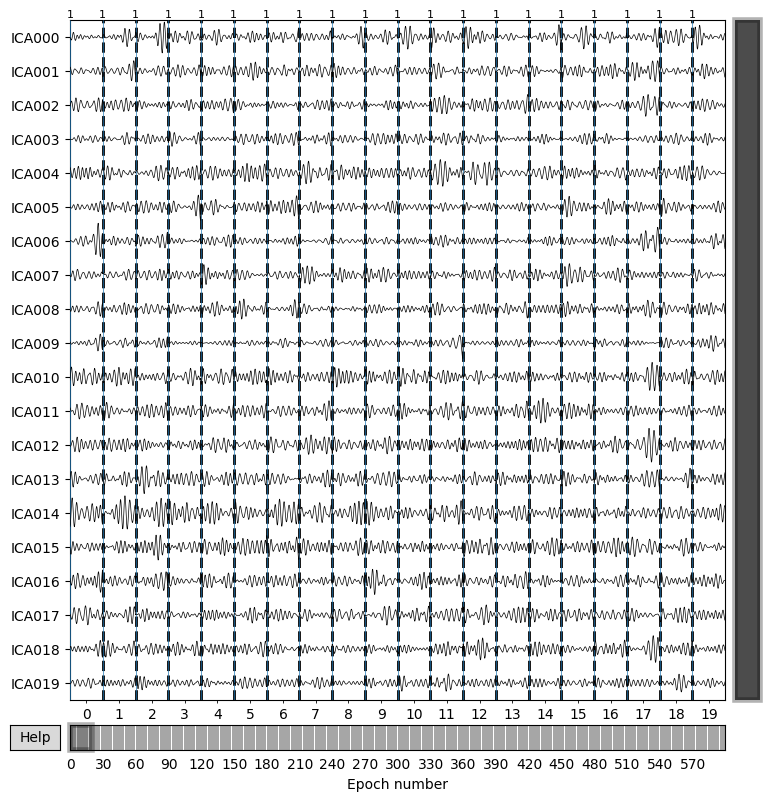

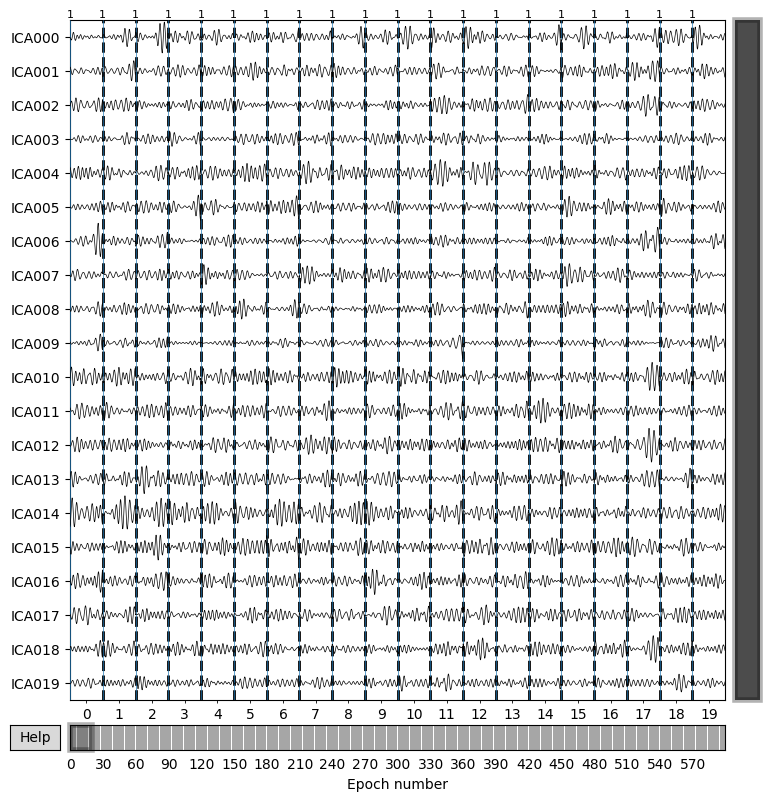

In [23]:
import mne
import numpy as np
from mne.preprocessing import ICA

montage_std = mne.channels.make_standard_montage('standard_1020')
std_ch_names = montage_std.ch_names[:62]

info = mne.create_info(ch_names=std_ch_names, sfreq=200, ch_types='eeg')
info.set_montage(montage_std)

data_mne = epochs_padronizadas.transpose(0, 2, 1)
epochs_mne = mne.EpochsArray(data_mne, info)

ica = ICA(n_components=20, random_state=42, method='fastica')
ica.fit(epochs_mne)

print("Mapas topográficos dos componentes ICA:")
ica.plot_components()

print("Séries temporais dos componentes ICA:")
ica.plot_sources(epochs_mne)

## 5.2 Definir componentes artefatuais

Após a inspeção visual, os componentes considerados artefatuais devem ser inseridos manualmente na lista `componentes_artefato`.

Critérios usados para marcação:

- topografia compatível com artefato ocular ou muscular;
- comportamento temporal com picos abruptos ou padrão não fisiológico;
- componente sem padrão compatível com atividade neural relevante para a tarefa.

No momento, a lista deve permanecer vazia até que os componentes sejam inspecionados e justificados.

In [24]:
componentes_artefato = []

ica.exclude = componentes_artefato

print(f"Componentes marcados para remoção: {ica.exclude}")

epochs_limpas = ica.apply(epochs_mne.copy())

epochs_padronizadas_clean = epochs_limpas.get_data().transpose(0, 2, 1)

print("\n" + "="*30)
print("PROCESSO ICA CONCLUÍDO")
print(f"Shape original: {epochs_padronizadas.shape}")
print(f"Shape após ICA: {epochs_padronizadas_clean.shape}")
print("="*30)

Componentes marcados para remoção: []
Applying ICA to Epochs instance
    Transforming to ICA space (20 components)
    Zeroing out 0 ICA components
    Projecting back using 62 PCA components



PROCESSO ICA CONCLUÍDO
Shape original: (600, 129, 62)
Shape após ICA: (600, 129, 62)


In [25]:
# célula adicionada para comparar as epochs antes e depois da ICA, verificando se são praticamente iguais (o que indicaria que nenhum componente foi removido)

diff = np.abs(epochs_padronizadas_clean - epochs_padronizadas)

print("Diferença máxima:", diff.max())
print("Diferença média:", diff.mean())
print("São praticamente iguais?", np.allclose(
    epochs_padronizadas_clean,
    epochs_padronizadas,
    atol=1e-10
))

Diferença máxima: 1.4210854715202004e-13
Diferença média: 2.9988969373821178e-15
São praticamente iguais? True


# 6. Modelo baseline: Welch + SVM

Esta abordagem estabelece o baseline espectral do projeto. A hipótese central é que a direção da atenção visual encoberta modula o ritmo Alfa nas regiões posteriores do cérebro. Portanto, a extração da densidade espectral de potência (PSD) dessa banda deve fornecer características discriminativas suficientes para que o classificador (SVM) separe as seis direções experimentais.


## 6.1 Extrair potência alfa via Welch

Nesta etapa, utilizamos o Método de Welch para focar no domínio da frequência e calcular a Densidade Espectral de Potência (PSD) em cada um dos 32 canais de forma independente.

A extração é intencionalmente restrita a 32 canais, focando nas áreas de interesse relacionadas ao ritmo Alfa (córtex parietal e occipital). Essa redução de dimensionalidade espacial é fundamental para mitigar o ruído de regiões menos relevantes (como as frontais) e prevenir o overfitting do modelo.


In [26]:
import numpy as np
from scipy.signal import welch

# fs = Frequência de amostragem do dataset
fs = 200

# SELEÇÃO TOPOGRÁFICA:
# Definimos os índices dos 32 canais posteriores (parietais e occipitais).
# a seleção manual de ROI (Region of Interest) é uma forma de filtragem
# espacial baseada na neurofisiologia da visão.
indices_canais = list(range(30, 62))
n_canais_selecionados = len(indices_canais)

X_welch_raw = []

print(f"Calculando PSD via Welch para {len(epochs_padronizadas_clean)} trials...")
print(f"Foco: {n_canais_selecionados} canais posteriores selecionados.")

for trial in epochs_padronizadas_clean:
    trial_psds = []

    for ch_idx in indices_canais:
        # SUAVIZAÇÃO DO ESTIMADOR (Welch):
        # nperseg=256: Define o tamanho da janela. Um valor maior aumenta a
        # resolução em frequência, mas aumenta a variância do estimador.
        # noverlap=128: Usamos 50% de sobreposição para suavizar o espectro e
        # reduzir o ruído inerente à Transformada de Fourier (FFT) pura.
        freqs, psd = welch(trial[:, ch_idx],
                           fs=fs,
                           nperseg=256,
                           noverlap=128)
        trial_psds.append(psd)

    X_welch_raw.append(trial_psds)

X_welch_raw = np.array(X_welch_raw)

# EXTRAÇÃO DA BANDA DE INTERESSE (Alfa):
# Criamos uma máscara booleana para isolar o intervalo de 8-14 Hz.
# dependemos da modulação natural desse ritmo para
# identificar o deslocamento da atenção.
idx_alfa = np.where((freqs >= 8) & (freqs <= 14))[0]

# Calculamos a potência média dentro da banda para reduzir cada canal a
# um único valor de feature por trial.
X_features_welch = np.mean(X_welch_raw[:, :, idx_alfa], axis=-1)

# NORMALIZAÇÃO LOGARÍTMICA:
# A potência do EEG segue uma distribuição de lei de potência (1/f).
# Aplicamos Log10 para tornar a distribuição das features mais Gaussiana,
# o que facilita a convergência do hiperplano do SVM.
# O termo '1e-10' (epsilon) evita o erro matemático de log(0).
X_features_welch = np.log10(X_features_welch + 1e-10)

print("\n" + "="*40)
print("PSD CALCULADO (WELCH SUAVIZADO)")
print(f"Shape bruto: {X_welch_raw.shape}")
print(f"Shape final para o SVM: {X_features_welch.shape}")
print(f"Canais processados: {n_canais_selecionados} (Posteriores)")
print("="*40)

Calculando PSD via Welch para 600 trials...
Foco: 32 canais posteriores selecionados.


C:\Users\Amanda\AppData\Local\Temp\ipykernel_16316\2401691863.py:28: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 129, using nperseg = 129
  freqs, psd = welch(trial[:, ch_idx],



PSD CALCULADO (WELCH SUAVIZADO)
Shape bruto: (600, 32, 65)
Shape final para o SVM: (600, 32)
Canais processados: 32 (Posteriores)


## 6.2 Padronizar features por z-score
Esta transformação é necessária antes da aplicação do classificador, pois padroniza os valores de potência da banda Alfa extraídos via Método de Welch. Isso garante que a potência de todos os eletrodos contribua de forma equilibrada para o aprendizado do modelo, evitando que canais com amplitudes naturalmente maiores se sobreponham em relação a outros.


In [27]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

X_padronizado = scaler.fit_transform(X_features_welch)

print("="*40)
print("VERIFICAÇÃO DA PADRONIZAÇÃO")
print(f"Shape final: {X_padronizado.shape}")

print("\nMédia das primeiras 5 features (Alvo ~ 0):")
print(np.mean(X_padronizado[:, :5], axis=0))

print("\nDesvio padrão das primeiras 5 features (Alvo = 1):")
print(np.std(X_padronizado[:, :5], axis=0))
print("="*40)

VERIFICAÇÃO DA PADRONIZAÇÃO
Shape final: (600, 32)

Média das primeiras 5 features (Alvo ~ 0):
[ 5.22730007e-17  3.75625457e-16  1.70141679e-16  4.95448590e-16
 -1.36464913e-16]

Desvio padrão das primeiras 5 features (Alvo = 1):
[1. 1. 1. 1. 1.]


## 6.3 Classificar com SVM e avaliar baseline:
Nesta fase do pipeline, implementamos o algoritmo de classificação Support Vector Machine (SVM) para categorizar os sinais de EEG em uma das 6 direções de atenção visual possíveis. O classificador utiliza como entrada a matriz de características já escalonada via Z-score, contendo a potência da banda Alfa de 32 canais posteriores.

A escolha do SVM fundamenta-se na sua robustez ao mapear os dados em um espaço de 32 dimensões (correspondentes aos eletrodos selecionados), buscando os hiperplanos que maximizam a margem de separação entre as classes. Para o multiclasse (6 direções), o modelo adota a estratégia One-Vs-One (OvO),criando fronteiras de decisão específicas para cada par de direções.

Devido ao número restrito de épocas (trials), o SVM é eficaz na prevenção do sobreajuste (overfitting), baseando sua fronteira de decisão apenas nas amostras mais importantes para definir os limites entre as classes (os vetores de suporte). O desempenho é validado via Validação Cruzada, garantindo que as acurácias obtidas de 20.50% (multiclasse) e de 62.77% (binária) demonstrem a capacidade do modelo de conseguir identificar os padrões de atenção no EEG.



Treinando modelo Binário...
Treinando modelo Multiclasse com proteção anti-colapso (F1-Macro)...

RESUMO DE PERFORMANCE (BASELINE)
Dados de Entrada: Welch + Log10 (Banda Alfa | 32 Canais)
Melhores parâmetros Multiclasse: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Acurácia Binária (Direção 0 vs 1): 62.77%
Acurácia Multiclasse (Todas as 6): 20.50%
Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)


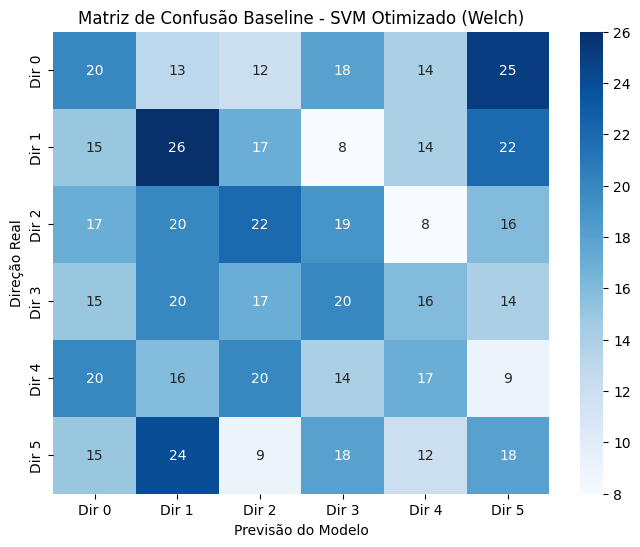

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_final = X_features_welch
y_final = labels_padronizadas

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', random_state=42))
])

param_grid_bin = {
    'svm__C': [0.1, 1, 10, 50, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['rbf', 'linear']
}

print("Treinando modelo Binário...")

p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_bin = GridSearchCV(
    pipe_svm,
    param_grid_bin,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_bin.fit(X_bin, y_bin)
melhor_modelo_bin = grid_bin.best_estimator_

acc_binaria = cross_val_score(
    melhor_modelo_bin,
    X_bin,
    y_bin,
    cv=cv,
    scoring='accuracy'
).mean()


# --- 3. OTIMIZAÇÃO MULTICLASSE  ---
# usamos 'f1_macro' para PROIBIR o SVM de ignorar classes.
# Também forçamos o formato 'ovo' (One-Vs-One) para que ele crie duelos diretos entre todas as classes.
param_grid_multi = {
    'svm__C': [0.1, 1, 10, 50, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['rbf']
}

print("Treinando modelo Multiclasse com proteção anti-colapso (F1-Macro)...")
grid_multi = GridSearchCV(
    pipe_svm,
    param_grid_multi,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_multi.fit(X_final, y_final)
melhor_modelo_multi = grid_multi.best_estimator_

acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv, scoring='accuracy').mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)

print("\n" + "="*50)
print(f"RESUMO DE PERFORMANCE (BASELINE)")
print("="*50)
print(f"Dados de Entrada: Welch + Log10 (Banda Alfa | {X_final.shape[1]} Canais)")
print(f"Melhores parâmetros Multiclasse: {grid_multi.best_params_}")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)


# --- 5. PLOT DA MATRIZ AZUL ---
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)

sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Dir {i}' for i in range(6)],
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Baseline - SVM Otimizado (Welch)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

In [29]:
# célula adicionada para testar a robustez do modelo com diferentes seeds, verificando se a acurácia se mantém estável ou se varia muito dependendo da seed escolhida

print("\nTeste de robustez com diferentes seeds:")

resultados = []

for seed in [0, 1, 2, 3, 4]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    acc = cross_val_score(
        melhor_modelo_multi,
        X_final,
        y_final,
        cv=cv,
        scoring='accuracy'
    ).mean()

    resultados.append(acc)

print("Resultados:", resultados)
print("Média:", np.mean(resultados))
print("Desvio padrão:", np.std(resultados))


Teste de robustez com diferentes seeds:


Resultados: [np.float64(0.18666666666666668), np.float64(0.18666666666666665), np.float64(0.1633333333333333), np.float64(0.18), np.float64(0.18833333333333332)]
Média: 0.181
Desvio padrão: 0.009285592184789424


In [30]:
# célula adicionada para mostrar o desempenho fold a fold, verificando se existem folds com desempenho muito abaixo dos outros (o que poderia indicar que o modelo tem dificuldade com certos tipos de dados ou que existe alguma variação significativa entre os folds)

print("\nDesempenho fold a fold — Welch:")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_welch = cross_val_score(
    melhor_modelo_multi,
    X_final,
    y_final,
    cv=cv,
    scoring='accuracy'
)

print("Acurácias por fold:", scores_welch)
print("Média:", scores_welch.mean())
print("Desvio padrão:", scores_welch.std())


Desempenho fold a fold — Welch:
Acurácias por fold: [0.175      0.2        0.21666667 0.19166667 0.24166667]
Média: 0.205
Desvio padrão: 0.022730302828309762


In [31]:
# célula adicionada para testar o modelo contra o acaso, embaralhando os rótulos e verificando se a acurácia cai para perto do nível de chance (o que indicaria que o modelo realmente aprendeu algo relevante dos dados e não apenas decorou padrões espúrios)

print("\nTeste contra o acaso — Welch + SVM com rótulos embaralhados:")

resultados_random_welch = []

for seed in [0, 1, 2, 3, 4]:
    rng = np.random.default_rng(seed)

    y_random = rng.permutation(y_final)

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    acc_random = cross_val_score(
        melhor_modelo_multi,
        X_final,
        y_random,
        cv=cv_seed,
        scoring='accuracy'
    ).mean()

    resultados_random_welch.append(acc_random)

print("Resultados Welch com rótulos embaralhados:", resultados_random_welch)
print("Média Welch random:", np.mean(resultados_random_welch))
print("Desvio padrão Welch random:", np.std(resultados_random_welch))

print("\nComparação:")
print(f"Welch real: {np.mean(resultados):.4f}")
print(f"Welch random: {np.mean(resultados_random_welch):.4f}")
print(f"Nível de chance teórico: {1/6:.4f}")


Teste contra o acaso — Welch + SVM com rótulos embaralhados:
Resultados Welch com rótulos embaralhados: [np.float64(0.15833333333333335), np.float64(0.17833333333333334), np.float64(0.14666666666666667), np.float64(0.17833333333333334), np.float64(0.19166666666666665)]
Média Welch random: 0.17066666666666666
Desvio padrão Welch random: 0.01604161255402128

Comparação:
Welch real: 0.1810
Welch random: 0.1707
Nível de chance teórico: 0.1667


## 6.4 Radar de desempenho por direção — Welch + SVM
Para melhorar a visualização dos resultados obtidos na matriz de confusão, implementamos o gráfico de um Radar de desempenho por direção, no qual os seis vértices do hexágono representam as diferentes direções de atenção visual do dataset (0 a 5)..

O objetivo é evidenciar a acurácia individual do sistema em cada uma das direções. Enquanto a linha pontilhada vermelha indica o nível de chance ao acaso (16,66%), a linha azul destaca a performance real do modelo, revelando uma sensibilidade maior na direção 1 (seguida pela direção 2). A linha verde tracejada representa a média global de 20,50%, permitindo observar que, embora o desempenho se aproxime do limiar de aleatoriedade em algumas classes (como nas direções 4 e 5), o modelo ainda consegue apresentar uma capacidade preditiva levemente superior ao acaso na maioria das direções.

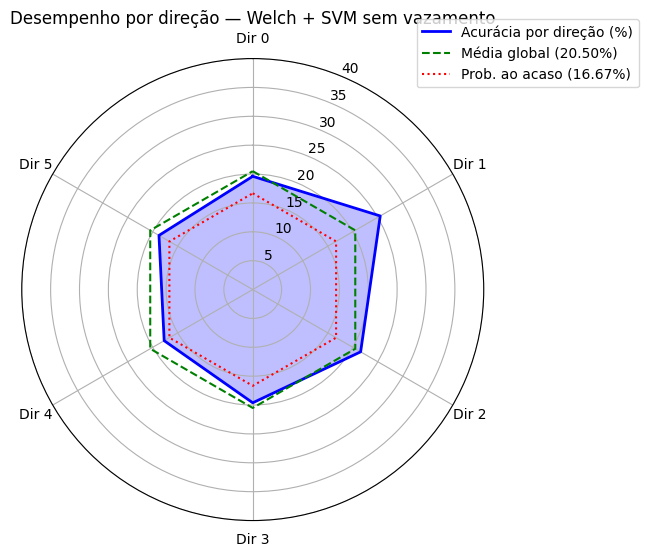

In [32]:
import numpy as np
import matplotlib.pyplot as plt

acertos = np.diag(matriz_confusao)
totais = matriz_confusao.sum(axis=1)
accuracy_per_dir = (acertos / totais) * 100

labels = [f'Dir {i}' for i in range(6)]
num_vars = len(labels)

stats = np.concatenate((accuracy_per_dir, [accuracy_per_dir[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.fill(angles, stats, color='blue', alpha=0.25)
ax.plot(angles, stats, color='blue', linewidth=2, label='Acurácia por direção (%)')

media_global_val = acc_multi * 100
media_global = [media_global_val] * (num_vars + 1)
ax.plot(angles, media_global, color='green', linestyle='--', label=f'Média global ({media_global_val:.2f}%)')

chance_val = 100 / 6
chance = [chance_val] * (num_vars + 1)
ax.plot(angles, chance, color='red', linestyle=':', label=f'Prob. ao acaso ({chance_val:.2f}%)')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, max(40, np.nanmax(accuracy_per_dir) + 10))

plt.title('Desempenho por direção — Welch + SVM sem vazamento')
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.10))
plt.show()


# 7. Modelo espacial: CSP + SVM

O CSP é usado para extrair componentes espaciais que maximizam diferenças entre classes. Diferentemente do Welch, que calcula potência por canal de forma independente, o CSP explora combinações espaciais entre canais.

Essa é a principal comparação metodológica do notebook:

- **Welch + SVM:** baseline espectral, sem filtro espacial supervisionado.
- **CSP + SVM:** abordagem espacial supervisionada, mais adequada para padrões distribuídos no EEG.


## 7.1 Extrair features espaciais com CSP


In [33]:
import numpy as np
from mne.decoding import CSP
# 1. PREPARAÇÃO DOS DADOS
X_time = np.transpose(epochs_padronizadas_clean, (0, 2, 1))
y = labels_padronizadas

# 2.
# Adicionamos 'rank' para garantir que canais redundantes não sujem a matriz
# O parâmetro 'cov_estimator' garante a maior robustez estatística possível
csp = CSP(n_components=10,
          reg='ledoit_wolf',
          rank='full',
          log=True,
          norm_trace=False)

print("Extraindo componentes espaciais otimizados...")
X_csp = csp.fit_transform(X_time, y)

# 3. CONEXÃO COM O SVM

X_features = X_csp

print("\n" + "="*40)
print("EXTRAÇÃO CSP FINALIZADA")
print(f"Shape para o SVM: {X_features.shape}")
print("Pode rodar o classificador.")
print("="*40)

Extraindo componentes espaciais otimizados...
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Estimating class=5 covariance using LEDOIT_WOLF
Done.

EXTRAÇÃO CSP FINALIZADA
Shape para o SVM: (600, 10)
Pode rodar o classificador.


# 7.2 Classificar features CSP com SVM:
Nesta fase do pipeline, implementamos o algoritmo de classificação Support Vector Machine (SVM) para categorizar os sinais de EEG a partir dos componentes espaciais extraídos pelo CSP. O classificador recebe como entrada as características (features) que já foram matematicamente otimizadas para maximizar a separação entre as seis direções de atenção visual possíveis.

A escolha do SVM justifica-se por sua robustez ao lidar com vetores de características em espaços de alta dimensionalidade. Para o problema multiclasse, o modelo utiliza a estratégia One-Vs-One (OvO), permitindo definir a fronteira de decisão mais estável para os padrões de variância projetados pelos filtros espaciais.

O desempenho é validado via Validação Cruzada Estratificada, mitigando o risco de sobreajuste (overfitting) e garantindo a generalização dos resultados. A acurácia obtida de 41.33% (multiclasse) e 75.01% (binária) demonstra a superioridade desta abordagem, evidenciando que a inclusão de informação espacial supervisionada permite uma identificação muito mais precisa dos padrões de atenção no EEG em comparação ao baseline espectral.



Iniciando busca pelos melhores parâmetros (isso pode levar alguns segundos)...
Melhores parâmetros binários: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Melhores parâmetros multiclasse: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Dados de Entrada: CSP + SVM | 10 componentes CSP
Acurácia Binária (Direção 0 vs 1): 75.01%
Acurácia Multiclasse (Todas as 6): 41.33%
Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)


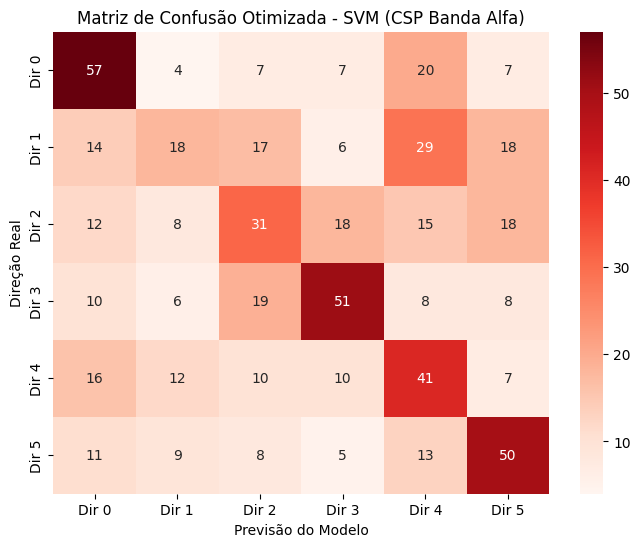

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix

# Usando as features espaciais extraídas pelo CSP
X_final = X_features
y_final = labels_padronizadas

# Configuração da Validação Cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OTIMIZAÇÃO VIA GRID SEARCH DO SVM:
# O parâmetro 'C' controla a regularização (equilíbrio entre margem e erro),
# enquanto o 'gamma' define o alcance da influência de cada ponto no kernel RBF.
# Testamos o kernel 'linear' para verificar se a filtragem do CSP já tornou
# os dados linearmente separáveis sem a necessidade de projeções complexas.
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

print("Iniciando busca pelos melhores parâmetros (isso pode levar alguns segundos)...")
# 'class_weight=balanced' é fundamental para lidar com o desequilíbrio entre as classes,
# ela ajusta os pesos para garantir que o SVM trate todas as direções com
# a mesma importância, mesmo que o sinal de uma classe seja menos proeminente.
grid_search = GridSearchCV(SVC(class_weight='balanced', random_state=42),
                           param_grid, cv=cv, scoring='accuracy')

# AVALIAÇÃO BINÁRIA:
# Realizar o duelo '0 vs 1' estabelece um teto de performance.
# Isso serve como controle para validar se o pipeline consegue separar
# direções opostas antes de enfrentar a complexidade do multiclasse.
p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_search.fit(X_bin, y_bin)
melhor_modelo_bin = grid_search.best_estimator_
acc_binaria = cross_val_score(melhor_modelo_bin, X_bin, y_bin, cv=cv).mean()
print(f"Melhores parâmetros binários: {grid_search.best_params_}")


# AVALIAÇÃO MULTICLASSE (Validação de 6 Direções):
# O GridSearchCV busca a configuração que melhor generaliza para
# distinguir as 6 direções de atenção simultaneamente.
grid_search.fit(X_final, y_final)
melhor_modelo_multi = grid_search.best_estimator_
acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv).mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)
print(f"Melhores parâmetros multiclasse: {grid_search.best_params_}")


# RELATÓRIO DE SAÍDA:
print("\n" + "="*50)
print("="*50)
print(f"Dados de Entrada: CSP + SVM | {X_final.shape[1]} componentes CSP")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)

# VISUALIZAÇÃO E DIAGNÓSTICO:
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)
# utilizamos o 'cmap=Reds' como um marcador visual de alta performance,
# o que facilita o contraste com o azul do baseline spectral.
# A análise da diagonal principal confirma onde o CSP foi mais efetivo.
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Reds',
            xticklabels=[f'Dir {i}' for i in range(6)],
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Otimizada - SVM (CSP Banda Alfa)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

In [35]:
# célula adicionada para testar a robustez do modelo com diferentes seeds, verificando se a acurácia se mantém estável ou se varia muito dependendo da seed escolhida

print("\nTeste de robustez CSP + SVM com diferentes seeds:")

resultados_csp = []

for seed in [0, 1, 2, 3, 4]:
    cv_seed = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    acc = cross_val_score(
        melhor_modelo_multi,
        X_final,
        y_final,
        cv=cv_seed,
        scoring='accuracy'
    ).mean()

    resultados_csp.append(acc)

print("Resultados CSP:", resultados_csp)
print("Média CSP:", np.mean(resultados_csp))
print("Desvio padrão CSP:", np.std(resultados_csp))


Teste de robustez CSP + SVM com diferentes seeds:


Resultados CSP: [np.float64(0.4166666666666667), np.float64(0.4133333333333334), np.float64(0.41833333333333333), np.float64(0.4183333333333333), np.float64(0.41666666666666663)]
Média CSP: 0.4166666666666667
Desvio padrão CSP: 0.0018257418583505249


In [36]:
# célula adicionada para mostrar o desempenho fold a fold, verificando se existem folds com desempenho muito abaixo dos outros (o que poderia indicar que o modelo tem dificuldade com certos tipos de dados ou que existe alguma variação significativa entre os folds)

print("\nDesempenho fold a fold — CSP + SVM:")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_csp = cross_val_score(
    melhor_modelo_multi,
    X_final,
    y_final,
    cv=cv,
    scoring='accuracy'
)

print("Acurácias por fold:", scores_csp)
print("Média:", scores_csp.mean())
print("Desvio padrão:", scores_csp.std())


Desempenho fold a fold — CSP + SVM:
Acurácias por fold: [0.45       0.425      0.40833333 0.4        0.38333333]
Média: 0.4133333333333333
Desvio padrão: 0.02273030282830975


In [37]:
# célula adicionada para testar o modelo contra o acaso, embaralhando os rótulos e verificando se a acurácia cai para perto do nível de chance (o que indicaria que o modelo realmente aprendeu algo relevante dos dados e não apenas decorou padrões espúrios)

print("\nTeste contra o acaso — CSP + SVM com rótulos embaralhados:")

resultados_random = []

for seed in [0, 1, 2, 3, 4]:
    rng = np.random.default_rng(seed)

    y_random = rng.permutation(y_final)

    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    acc_random = cross_val_score(
        melhor_modelo_multi,
        X_final,
        y_random,
        cv=cv_seed,
        scoring='accuracy'
    ).mean()

    resultados_random.append(acc_random)

print("Resultados com rótulos embaralhados:", resultados_random)
print("Média random:", np.mean(resultados_random))
print("Desvio padrão random:", np.std(resultados_random))

print("\nComparação:")
print(f"CSP real: {np.mean(resultados_csp):.4f}")
print(f"CSP random: {np.mean(resultados_random):.4f}")
print(f"Nível de chance teórico: {1/6:.4f}")


Teste contra o acaso — CSP + SVM com rótulos embaralhados:
Resultados com rótulos embaralhados: [np.float64(0.15333333333333335), np.float64(0.175), np.float64(0.19), np.float64(0.15833333333333333), np.float64(0.16999999999999998)]
Média random: 0.16933333333333334
Desvio padrão random: 0.012935738607954834

Comparação:
CSP real: 0.4167
CSP random: 0.1693
Nível de chance teórico: 0.1667


## 7.3 Radar de desempenho por direção — CSP + SVM:

 Seguindo o mesmo raciocínio da matriz de confusão do Welch + SVM, vamos melhorar a visualização dos resultados obtidos na matriz de confusão do CSP + SVM implementando o gráfico de um Radar de desempenho por direção, no qual os seis vértices do hexágono representam as diferentes direções de atenção visual do dataset (0 a 5).

 O objetivo é verificar se a inclusão de informações espaciais, intrínseca ao algoritmo CSP, resulta em uma distribuição de acertos mais equilibrada ou se acentua a dominância de classes específicas. A linha pontilhada vermelha representa a probabilidade do acaso (16,66%), e a linha azul destaca a performance real do modelo, revelando uma sensibilidade consideravelmente maior no eixo vertical (direções 0 e 3) e nas direções adjacentes à esquerda (direções 4 e 5). A linha verde tracejada destaca média global de 41,33%, permitindo observar que, embora exista uma nítida assimetria na classificação, com a direção 1 apresentando o maior desafio e operando muito próxima à linha de aleatoriedade, a capacidade preditiva geral do classificador se manteve de forma consistente e substancialmente superior ao limite de "chute" na grande maioria das classes, validando a eficácia da filtragem espacial.

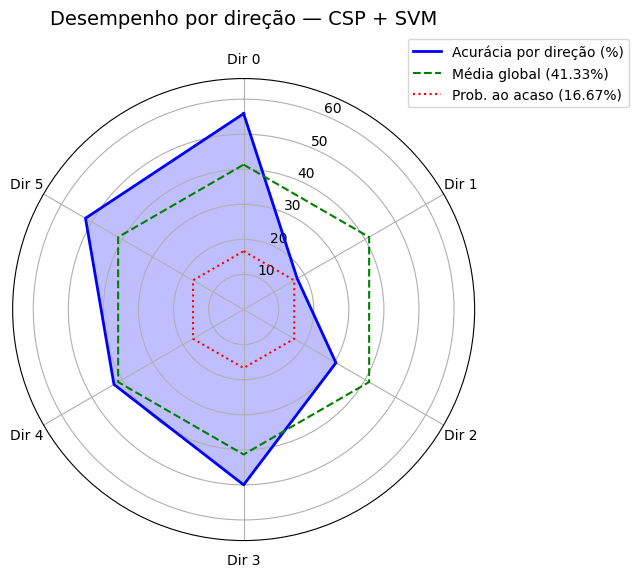

In [38]:
import numpy as np
import matplotlib.pyplot as plt

acertos = np.diag(matriz_confusao)
totais = matriz_confusao.sum(axis=1)
accuracy_per_dir = (acertos / totais) * 100

labels = [f'Dir {i}' for i in range(6)]
num_vars = len(labels)

stats = np.concatenate((accuracy_per_dir, [accuracy_per_dir[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.fill(angles, stats, color='blue', alpha=0.25)
ax.plot(angles, stats, color='blue', linewidth=2, label='Acurácia por direção (%)')

media_global_val = acc_multi * 100
media_global = [media_global_val] * (num_vars + 1)
ax.plot(angles, media_global, color='green', linestyle='--', label=f'Média global ({media_global_val:.2f}%)')

chance_val = 100 / 6
chance = [chance_val] * (num_vars + 1)
ax.plot(angles, chance, color='red', linestyle=':', label=f'Prob. ao acaso ({chance_val:.2f}%)')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, max(40, np.nanmax(accuracy_per_dir) + 10))

plt.title('Desempenho por direção — CSP + SVM', size=14, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.10))
plt.show()


# 8. Interpretação técnica dos resultados

É importante destacar a evolução conceitual que norteou as escolhas deste projeto. Inicialmente, a hipótese de trabalho sugeria que, devido ao forte envolvimento do domínio da frequência na tarefa de atenção, o processamento poderia seguir um molde similar de um sistema baseado em Steady-State Visual Evoked Potentials (SSVEP). Contudo, ao longo do desenvolvimento, percebeu-se que tal abordagem era insuficiente devido à ausência de potenciais evocados rítmicos constantes. A modulação da banda Alfa ligada à atenção apresenta características oscilatórias endógenas (8-14 Hz), diferindo drasticamente de um flicker externo piscando a uma frequência fixa.

Portanto, embora os modelos preliminares focados estritamente no domínio da frequência tenham obtido um desempenho apenas discretamente superior ao nível de chance (como observado no pipeline Welch), a transição para uma arquitetura analítica inspirada na decodificação de Ritmos Sensorimotores (SMR) revelou-se a decisão metodológica mais correta. Essa escolha justifica-se pelo sucesso da integração do algoritmo Common Spatial Patterns (CSP), que permitiu atingir níveis de acurácia binária similares aos do artigo do dataset, além de possibilitar a extração de variações de potência espacialmente distribuídas. Estas foram tratadas como assinaturas topográficas da intenção de atenção, de forma análoga à decodificação de padrões de imagética motora.

## 8.1 Resultado principal e Análise Direcional dos radares

Quantitativamente, observou-se que o baseline Welch + SVM apresentou acurácia multiclasse em torno de 18-20%, valor ainda muito próximo ao nível de chance aleatória (16,66%). Esse resultado indica que a potência média da banda alfa por canal, analisada de forma independente, possui baixa capacidade de discriminação entre as seis direções de atenção.

Em contrapartida, o pipeline CSP + SVM apresentou desempenho significativamente superior, atingindo valores próximos de 41% de acurácia multiclasse. Esse resultado representa um ganho expressivo em relação ao acaso, sugerindo que a informação neural relevante para a tarefa está fortemente associada à organização espacial do sinal, e não apenas à sua potência espectral.

A análise direcional por meio dos gráficos de radar revela nuances importantes sobre o comportamento dos classificadores. O modelo baseado em Welch apresenta comportamento majoritariamente instável, margeando o acaso em diversas classes (notadamente nas direções 4 e 5), apresentando uma sensibilidade preditiva apenas marginalmente superior na direção 1. Já o pipeline CSP, ao contrário de um ganho uniforme, revela uma nítida assimetria de classificação após a aplicação dos filtros espaciais. O classificador demonstrou excelente robustez no eixo vertical (direções 0 e 3) e nas direções adjacentes à esquerda (4 e 5), mas apresentou acentuada dificuldade na direção 1, operando muito próxima à linha de aleatoriedade para esta classe específica.

Adicionalmente, foi investigada a aplicação da Independent Component Analysis (ICA) como etapa de limpeza de artefatos. Inicialmente, foram realizados testes com exclusão arbitrária de componentes, o que resultou em redução do desempenho do modelo. Esse comportamento indicou que tais componentes possivelmente continham informação neural relevante para a tarefa. Posteriormente, foi realizada inspeção dos mapas topográficos e das séries temporais dos componentes independentes, não sendo identificados artefatos evidentes que justificassem sua remoção. Dessa forma, optou-se por não excluir componentes nesta etapa.

Verificou-se que, na ausência de exclusão, os dados reconstruídos pela ICA são numericamente equivalentes aos dados originais, caracterizando o uso da técnica como análise exploratória metodológica, sem impacto direto no pipeline final de classificação.

Por fim, embora o cenário binário também apresente desempenho superior ao nível de chance (50%), a análise detalhada de robustez e não aleatoriedade foi concentrada no cenário multiclasse por representar um problema computacional mais desafiador e informativo para a avaliação da eficácia dos modelos.

---

## 8.2 Avaliação da robustez e não aleatoriedade dos resultados

Para avaliar se os resultados observados são de fato decorrentes da capacidade do modelo em capturar padrões relevantes, e não de efeitos aleatórios ou específicos de uma única divisão dos dados, foram realizados três testes complementares.

### (1) Robustez a diferentes divisões dos dados (múltiplas seeds)

O modelo foi avaliado utilizando diferentes inicializações da validação cruzada, alterando o parâmetro `random_state`. Esse teste verifica se o desempenho depende da forma como os dados são particionados em treino e teste.

Os resultados mostraram que:

* o modelo baseado em Welch apresentou desempenho estável, porém próximo ao acaso;
* o modelo baseado em CSP apresentou desempenho altamente consistente, com baixa variabilidade entre execuções.

Esse comportamento indica que os resultados não são dependentes de uma única divisão específica dos dados.

---

### (2) Estabilidade entre folds da validação cruzada

Foi analisada a variação da acurácia entre os diferentes folds da validação cruzada.

Observou-se que ambos os modelos apresentaram desvios padrão semelhantes (~2,3%), indicando estabilidade no processo de avaliação. No entanto, apesar de apresentarem variabilidade semelhante, os níveis de acurácia são substancialmente diferentes, o que sugere que a diferença de desempenho não está relacionada à instabilidade do modelo, mas sim à qualidade das features utilizadas.

---

### (3) Teste com rótulos embaralhados (controle negativo)

Como controle adicional, os rótulos das classes foram embaralhados aleatoriamente, mantendo os dados de entrada inalterados. Esse teste permite avaliar o desempenho esperado caso não exista relação real entre os dados e os rótulos.

Os resultados mostraram que:

* o modelo **Welch + SVM** apresentou acurácia real (~18%) muito próxima da obtida com rótulos embaralhados (~17%), indicando ausência de ganho discriminativo relevante;
* o modelo **CSP + SVM** apresentou acurácia real (~41%) significativamente superior ao desempenho com rótulos embaralhados (~17%), evidenciando que o modelo está capturando informação discriminativa real presente nos dados.

Esse teste fornece forte evidência de que o desempenho do CSP não é decorrente de aleatoriedade.

---

##  8.3 Interpretação para o relatório

Os resultados obtidos indicam que a informação relevante para a tarefa de decodificação da atenção visual encoberta não está apenas na potência da banda alfa, mas na sua distribuição espacial entre os canais.

A abordagem baseada em Welch, por considerar apenas a potência espectral de forma independente por canal, apresenta desempenho limitado e próximo ao acaso. Em contraste, o CSP explora a estrutura espacial do sinal, identificando combinações lineares de canais que maximizam a separação entre classes.

A melhora substancial observada com o CSP, aliada à forte evidência fornecida pelos testes de robustez e pelo controle negativo com rótulos embaralhados, sugere que o modelo está, de fato, capturando padrões discriminativos reais. Contudo, a análise direcional revelou que essa captação de padrões não ocorre de maneira homogênea: a assimetria observada na classificação sugere que certas direções de foco atencional geram assinaturas espaciais mais facilmente isoláveis pelo algoritmo do que outras.

Além disso, a utilização de um pipeline integrado na validação cruzada garantiu que etapas de pré-processamento, como a normalização, fossem realizadas sem vazamento de informação, tornando a avaliação mais confiável.

É importante destacar a evolução conceitual que norteou as escolhas deste projeto. Inicialmente, a hipótese de trabalho sugeria que, devido ao forte envolvimento do domínio da frequência na tarefa de atenção, o processamento poderia seguir um molde similar de um sistema baseado em Steady-State Visual Evoked Potentials (SSVEP). Contudo, ao longo do desenvolvimento, percebeu-se que tal abordagem era insuficiente devido à ausência de potenciais evocados rítmicos constantes. A modulação da banda Alfa ligada à atenção apresenta características oscilatórias endógenas (8-14 Hz), diferindo drasticamente de um flicker externo piscando a uma frequência fixa.

Portanto, embora os modelos preliminares focados estritamente no domínio da frequência tenham obtido um desempenho apenas discretamente superior ao nível de chance (como observado no pipeline Welch), a transição para uma arquitetura analítica inspirada na decodificação de Ritmos Sensorimotores (SMR) revelou-se a decisão metodológica mais correta. Essa escolha justifica-se pelo sucesso da integração do algoritmo Common Spatial Patterns (CSP), que permitiu atingir níveis de acurácia binária similares aos do artigo do dataset, além de possibilitar a extração de variações de potência espacialmente distribuídas. Estas foram tratadas como assinaturas topográficas da intenção de atenção, de forma análoga à decodificação de padrões de imagética motora.

---

## 8.4 Limitações

Apesar dos resultados obtidos, algumas limitações devem ser consideradas:

* os experimentos apresentados nesta etapa foram conduzidos com um único participante, sendo a extensão para múltiplos sujeitos explorada em uma análise complementar em desenvolvimento;;
* não foram conduzidos testes estatísticos formais (ex.: testes de hipótese ou intervalos de confiança), sendo a análise baseada em evidências empíricas de robustez e comparação com controles negativos;
* a utilização da ICA foi limitada à análise exploratória, não sendo realizada remoção de componentes devido à ausência de artefatos claramente identificáveis;
* não há validação inter-sujeitos neste estágio.

Dessa forma, os resultados devem ser interpretados como evidências consistentes dentro do escopo do experimento, mas não como conclusões definitivas sobre generalização do modelo.